<style>
.jp-RenderedHTMLCommon table {
    margin-left: 0 !important;
    margin-right: auto !important;
}
</style>

# HAA methods

## Overview
The elicitation workshop produced a pooled mixture distribution capturing the views of 8 experts on our quantity of interest (QOI): **the percentage of remaining life expectancy spent free of disability**. This mixture comprises 8 equally-weighted split normal components — one per expert — but has no closed-form expression, meaning samples cannot be drawn from it directly. We therefore consider three candidate approaches for generating health-adjusted age samples in the NHP model, and compare their relative strengths and weaknesses below.

### 1. Direct quantile-based *(external pre-simulation)*

All sampling occurs *outside the model*. At runtime, the model receives precomputed quantiles and samples from them uniformly.

**Inputs:** Precomputed quantiles from mixture distributions for each *year × sex* combination

| Strengths | Limitations |
|-----------|-------------|
| Simple | Expensive pre-simulation step |
| Deterministic | Approximation of the true distribution |
| Model lightweight | Inflexible |

### 2. Mixture-based *(internal simulation using component parameters)*

Sampling is performed *within the model* in two steps: first, a component is selected according to the mixture weights; second, a sample is drawn from that component.

**Inputs:** Component parameters for each *year × sex* combination

| Strengths | Limitations |
|-----------|-------------|
| Exact representation of mixture | More complex than option 1 |
| Flexible | Slower per sample |
| No pre-simulation required | Input size grows with mixture complexity |
| . | Reproducibility depends on RNG seeding |

### 3. Metalog approximation

The model draws directly from a single continuous metalog distribution fitted to approximate the mixture.

**Inputs:** Fitted metalog parameters for each *year × sex* combination

| Strengths | Limitations |
|-----------|-------------|
| Compact and efficient | Minor tail approximation errors |
| Smooth approximation | Requires a fitting step |
| Reproducible | Risk of overfitting |


## Metalog approximation proof of concept
The [metalog distribution](https://en.wikipedia.org/wiki/Metalog_distribution) is a highly flexible, closed-form probability distribution designed to approximate virtually any continuous probability distribution using a simple polynomial form. It was introduced by [Tom Keelin](https://pubsonline.informs.org/doi/10.1287/deca.2016.0338) in 2016. Unlike traditional distributions (like normal or lognormal), the metalog:

- Has no fixed shape
- Can model bounded or unbounded data
- Has a closed-form quantile function
- Is easy to fit using linear regression
- Can represent symmetric, skewed, heavy-tailed, or multimodal shapes

It has proved especially popular in Decision science, Engineering risk assessment, and Bayesian modeling.

[**metalog-jax**](https://github.com/tjefferies/metalog_jax) is a new python package that implements the metalog distribution.

Below, we use metalog-jax to fit a metalog distribution (bounded on [0, 100]) to the QOI mixture distribution. The agreement is very strong, indicating that the metalog provides a good engineering approximation to the original mixture.

Data points: 800000
Data range: [5.11, 100.00]


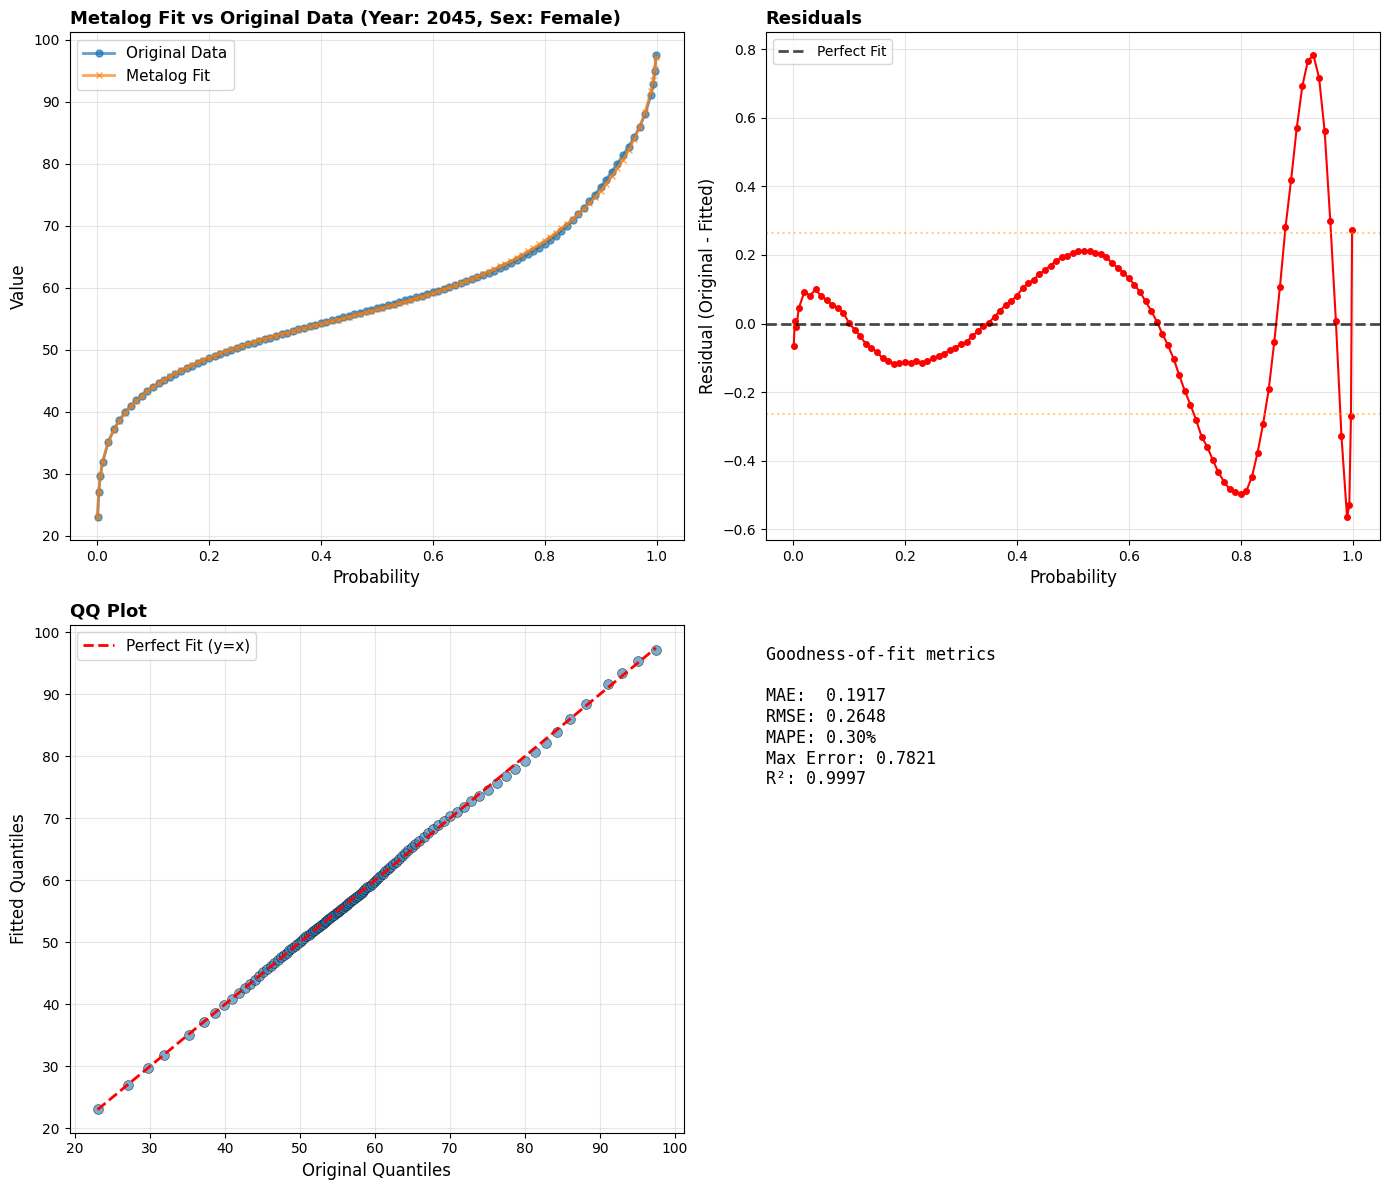

In [1]:
# dependencies: jax, metalog-jax, pandas, matplotlib, numpy
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metalog_jax.base import (
    MetalogBoundedness,
    MetalogFitMethod,
    MetalogInputData,
    MetalogParameters,
)
from metalog_jax.metalog import fit
from metalog_jax.utils import DEFAULT_Y

# 1. read data ----
# mixtures data
df = pd.read_parquet("../data_raw/mixtures.parquet")

# filter for specific combination of year and sex
df_filtered = df[(df["year"] == 2045) & (df["sex"] == "f")]

# extract and flatten mix_vals column into a 1D array
mix_arr = df_filtered["mix_vals"].explode().astype(float).to_numpy()

print(f"Data points: {len(mix_arr)}")
print(f"Data range: [{mix_arr.min():.2f}, {mix_arr.max():.2f}]")

# 2. fit metalog distribution ----
data = MetalogInputData.from_values(mix_arr, DEFAULT_Y, precomputed_quantiles=False)

# configure the metalog distribution
# - bounded between 0-100
# - OLS method for fitting
# - 6 terms
params = MetalogParameters(
    boundedness=MetalogBoundedness.BOUNDED,
    lower_bound=0.0,
    upper_bound=100.0,
    method=MetalogFitMethod.OLS,
    num_terms=6,
)

# fit the metalog distribution to the data
metalog = fit(data, params)

# 3. compute quantiles for comparison ----
# fitted quantiles from the metalog dist.
fitted_quantiles = metalog.ppf(DEFAULT_Y)

# empirical quantiles from the original data
mix_quantiles = jnp.quantile(mix_arr, DEFAULT_Y)

# 4. plot comparisons ----
# P1 quantile comparison; P2 residuals; p3 QQ plot; P4 goodness-of-fit metrics
# create 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# flatten for easier indexing (optional but cleaner)
ax1, ax2, ax3, ax4 = axes.flatten()

# P1 quantile comparison
ax1.plot(
    DEFAULT_Y,
    mix_quantiles,
    label="Original Data",
    marker="o",
    markersize=5,
    linewidth=2,
    alpha=0.7,
)
ax1.plot(
    DEFAULT_Y,
    fitted_quantiles,
    label="Metalog Fit",
    marker="x",
    markersize=5,
    linewidth=2,
    alpha=0.7,
)
ax1.set_xlabel("Probability", fontsize=12)
ax1.set_ylabel("Value", fontsize=12)
ax1.legend(fontsize=11, loc="best")
ax1.grid(True, alpha=0.3)
ax1.set_title(
    "Metalog Fit vs Original Data (Year: 2045, Sex: Female)",
    fontsize=13,
    fontweight="bold",
    loc="left",
)

# shade region between curves
ax1.fill_between(
    DEFAULT_Y,
    mix_quantiles,
    fitted_quantiles,
    alpha=0.2,
    color="gray",
    label="Difference",
)

# P2 residuals
residuals = mix_quantiles - fitted_quantiles
ax2.plot(DEFAULT_Y, residuals, color="red", marker="o", markersize=4, linewidth=1.5)
ax2.axhline(
    y=0, color="black", linestyle="--", linewidth=2, alpha=0.7, label="Perfect Fit"
)
ax2.set_xlabel("Probability", fontsize=12)
ax2.set_ylabel("Residual (Original - Fitted)", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_title("Residuals", fontsize=13, fontweight="bold", loc="left")
ax2.legend(fontsize=10)

# add reference lines at ±1 sd of residuals
residual_std = np.std(residuals)
ax2.axhline(
    y=residual_std,
    color="orange",
    linestyle=":",
    alpha=0.5,
    label=f"±1 SD ({residual_std:.2f})",
)
ax2.axhline(y=-residual_std, color="orange", linestyle=":", alpha=0.5)

# P3 QQ plot
ax3.scatter(
    mix_quantiles, fitted_quantiles, alpha=0.6, s=50, edgecolors="black", linewidth=0.5
)
ax3.plot(
    [mix_quantiles.min(), mix_quantiles.max()],
    [mix_quantiles.min(), mix_quantiles.max()],
    "r--",
    linewidth=2,
    label="Perfect Fit (y=x)",
)
ax3.set_xlabel("Original Quantiles", fontsize=12)
ax3.set_ylabel("Fitted Quantiles", fontsize=12)
ax3.legend(fontsize=11)
ax3.set_title("QQ Plot", fontsize=13, fontweight="bold", loc="left")
ax3.grid(True, alpha=0.3)

# P4 goodness-of-fit metrics
mae = np.mean(np.abs(mix_quantiles - fitted_quantiles))
rmse = np.sqrt(np.mean((mix_quantiles - fitted_quantiles) ** 2))
mape = np.mean(np.abs((mix_quantiles - fitted_quantiles) / mix_quantiles)) * 100

# additional metrics
max_error = np.max(np.abs(mix_quantiles - fitted_quantiles))
r_squared = 1 - (
    np.sum(residuals**2) / np.sum((mix_quantiles - np.mean(mix_quantiles)) ** 2)
)

ax4.axis("off")
metrics_text = f"""
Goodness-of-fit metrics

MAE:  {mae:.4f}
RMSE: {rmse:.4f}
MAPE: {mape:.2f}%
Max Error: {max_error:.4f}
R²: {r_squared:.4f}
"""

ax4.text(
    0.0,
    1.0,
    metrics_text,
    fontsize=12,
    family="monospace",
    verticalalignment="top",
    horizontalalignment="left",
    transform=ax4.transAxes,
)

plt.tight_layout()
plt.show()

### Choosing the number of terms
While the fit can be improved further by increasing the number of metalog terms, this introduces an inherent trade-off. Using too many terms can lead to overfitting of minor sampling noise, potential numerical instability (particularly in the tails), and a less transparent or more unwieldy parameterization.

Below, we compare the goodness of fit for metalog distributions with 7, 9, and 11 terms, respectively. Improvements beyond 9 terms are minimal, suggesting that additional terms offer little, if any, practical benefit. On this basis, a 9-term metalog is recommended as providing an appropriate balance between accuracy and parsimony.

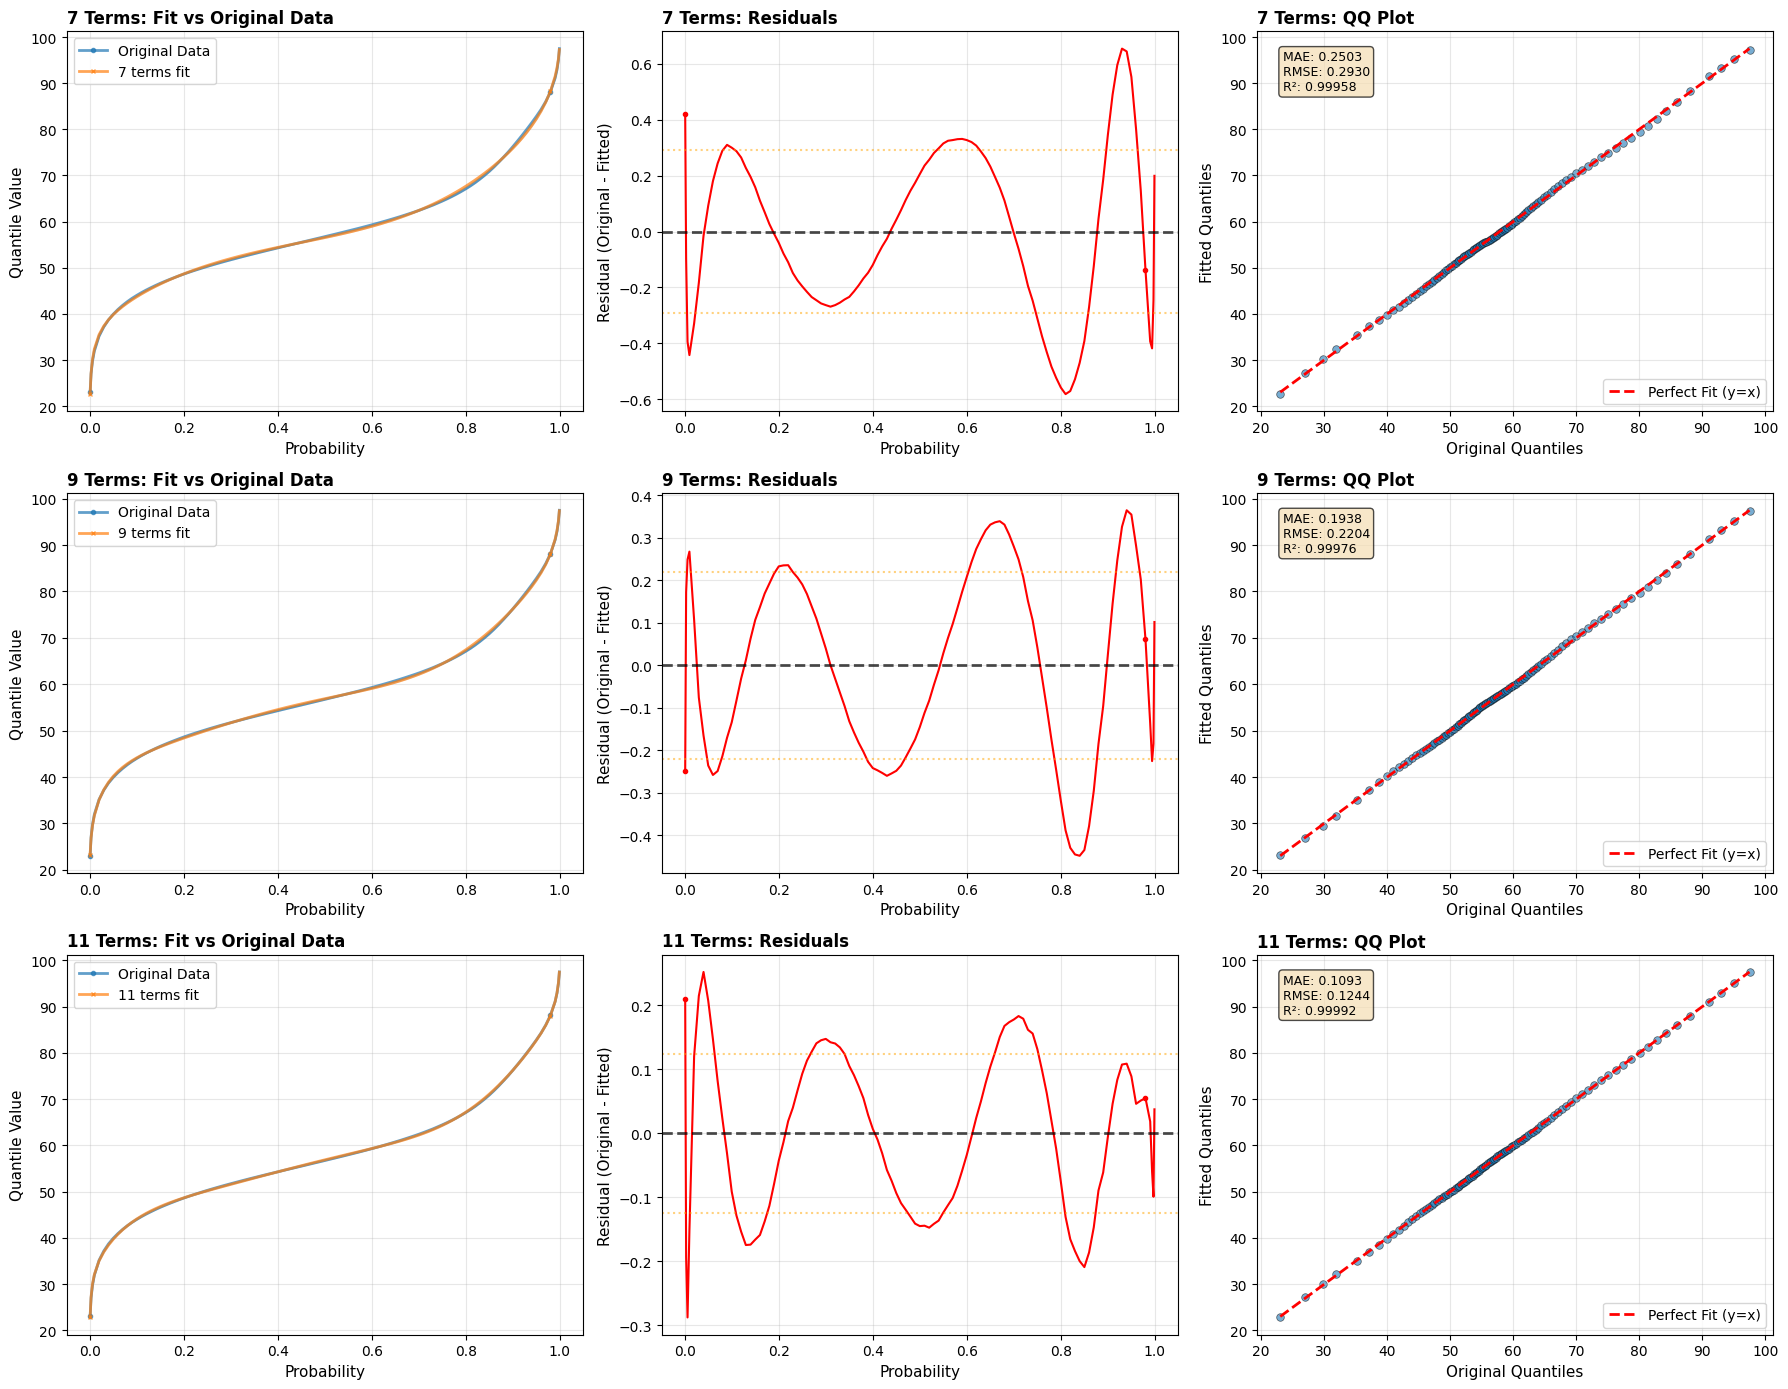


TERM COMPARISON SUMMARY
Terms      MAE          RMSE         R²           Max Error   
----------------------------------------------------------------------
7          0.2503       0.2930       0.999576     0.6546      
9          0.1938       0.2204       0.999760     0.4477      
11         0.1093       0.1244       0.999924     0.2879      

MAX DIFFERENCE VS 11-TERM FIT:
  7 terms: 0.5473
  9 terms: 0.5366


In [2]:
# Choosing the optimal number of terms
# Probability grid for evaluation
p_grid = DEFAULT_Y


# Function to fit metalog with given terms and return quantiles
def fit_metalog(values, n_terms):
    data = MetalogInputData.from_values(mix_arr, DEFAULT_Y, precomputed_quantiles=False)
    params = MetalogParameters(
        boundedness=MetalogBoundedness.BOUNDED,
        lower_bound=0.0,
        upper_bound=100.0,
        method=MetalogFitMethod.OLS,
        num_terms=n_terms,
    )
    metalog = fit(data, params)
    return metalog.ppf(p_grid)


# Fit metalogs with different numbers of terms
quantiles_7 = fit_metalog(mix_arr, 7)
quantiles_9 = fit_metalog(mix_arr, 9)
quantiles_11 = fit_metalog(mix_arr, 11)

# Get empirical quantiles at the same probability grid for comparison
mix_quantiles_grid = jnp.quantile(mix_arr, p_grid)

# ============================================================================
# VISUALIZATION: 3x3 GRID (ONE ROW PER TERM COUNT)
# ============================================================================

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# Data for each term count
term_data = [
    (7, quantiles_7, "7 Terms"),
    (9, quantiles_9, "9 Terms"),
    (11, quantiles_11, "11 Terms"),
]

for row, (n_terms, fitted_quantiles, title) in enumerate(term_data):
    # Column 1: Quantile comparison
    ax_comp = axes[row, 0]
    ax_comp.plot(
        p_grid,
        mix_quantiles_grid,
        label="Original Data",
        marker="o",
        markersize=3,
        linewidth=2,
        alpha=0.7,
        markevery=100,
    )
    ax_comp.plot(
        p_grid,
        fitted_quantiles,
        label=f"{n_terms} terms fit",
        marker="x",
        markersize=3,
        linewidth=2,
        alpha=0.7,
        markevery=100,
    )
    ax_comp.set_xlabel("Probability", fontsize=11)
    ax_comp.set_ylabel("Quantile Value", fontsize=11)
    ax_comp.legend(fontsize=10, loc="best")
    ax_comp.grid(True, alpha=0.3)
    ax_comp.set_title(
        f"{title}: Fit vs Original Data", fontsize=12, fontweight="bold", loc="left"
    )
    ax_comp.fill_between(
        p_grid, mix_quantiles_grid, fitted_quantiles, alpha=0.2, color="gray"
    )

    # Column 2: Residuals
    ax_resid = axes[row, 1]
    residuals = mix_quantiles_grid - fitted_quantiles
    ax_resid.plot(
        p_grid,
        residuals,
        color="red",
        marker="o",
        markersize=3,
        linewidth=1.5,
        markevery=100,
    )
    ax_resid.axhline(y=0, color="black", linestyle="--", linewidth=2, alpha=0.7)
    ax_resid.set_xlabel("Probability", fontsize=11)
    ax_resid.set_ylabel("Residual (Original - Fitted)", fontsize=11)
    ax_resid.grid(True, alpha=0.3)
    ax_resid.set_title(
        f"{title}: Residuals", fontsize=12, fontweight="bold", loc="left"
    )

    # Add ±1 SD reference lines
    residual_std = np.std(residuals)
    ax_resid.axhline(
        y=residual_std, color="orange", linestyle=":", alpha=0.5, linewidth=1.5
    )
    ax_resid.axhline(
        y=-residual_std, color="orange", linestyle=":", alpha=0.5, linewidth=1.5
    )

    # Column 3: QQ Plot
    ax_qq = axes[row, 2]
    ax_qq.scatter(
        mix_quantiles_grid,
        fitted_quantiles,
        alpha=0.6,
        s=30,
        edgecolors="black",
        linewidth=0.5,
    )
    ax_qq.plot(
        [mix_quantiles_grid.min(), mix_quantiles_grid.max()],
        [mix_quantiles_grid.min(), mix_quantiles_grid.max()],
        "r--",
        linewidth=2,
        label="Perfect Fit (y=x)",
    )
    ax_qq.set_xlabel("Original Quantiles", fontsize=11)
    ax_qq.set_ylabel("Fitted Quantiles", fontsize=11)
    ax_qq.legend(fontsize=10)
    ax_qq.set_title(f"{title}: QQ Plot", fontsize=12, fontweight="bold", loc="left")
    ax_qq.grid(True, alpha=0.3)

    # Calculate and display metrics on QQ plot
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    r_squared = 1 - (
        np.sum(residuals**2)
        / np.sum((mix_quantiles_grid - np.mean(mix_quantiles_grid)) ** 2)
    )

    metrics_text = f"MAE: {mae:.4f}\nRMSE: {rmse:.4f}\nR²: {r_squared:.5f}"
    ax_qq.text(
        0.05,
        0.95,
        metrics_text,
        transform=ax_qq.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7),
    )

plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY COMPARISON
# ============================================================================

print("\n" + "=" * 70)
print("TERM COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Terms':<10} {'MAE':<12} {'RMSE':<12} {'R²':<12} {'Max Error':<12}")
print("-" * 70)

for n_terms, quantiles in [(7, quantiles_7), (9, quantiles_9), (11, quantiles_11)]:
    residuals = mix_quantiles_grid - quantiles
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    max_error = np.max(np.abs(residuals))
    r_squared = 1 - (
        np.sum(residuals**2)
        / np.sum((mix_quantiles_grid - np.mean(mix_quantiles_grid)) ** 2)
    )
    print(
        f"{n_terms:<10} {mae:<12.4f} {rmse:<12.4f} {r_squared:<12.6f} {max_error:<12.4f}" # noqa: E501
    )

print("=" * 70)
print("\nMAX DIFFERENCE VS 11-TERM FIT:")
for n, q in zip([7, 9], [quantiles_7, quantiles_9]):
    diff = np.max(np.abs(q - quantiles_11))
    print(f"  {n} terms: {diff:.4f}")
print("=" * 70)